In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
import joblib

In [2]:
print("Generating environmental dataset")
np.random.seed(42)
timesteps = 4000

Generating environmental dataset


In [3]:
time_axis = np.linspace(0, 150, timesteps)
traffic_seq = 50 + 35 * np.sin(time_axis) + np.random.uniform(-7, 7, timesteps)
wind_seq = 15 + 10 * np.cos(time_axis * 0.5) + np.random.uniform(-3, 3, timesteps)
factory_seq = 60 + 20 * np.sin(time_axis * 1.2) + np.random.uniform(-12, 12, timesteps)
temp_seq = 28 + 8 * np.sin(time_axis - 1.5) + np.random.uniform(-2, 2, timesteps)

In [5]:
##physical dynamics equation
base_aqi=(traffic_seq*1.4)+(factory_seq*1.1)-(wind_seq*1.6)+(temp_seq*0.3)+30

In [6]:
##real worrld ki sensor pluctuation ke liye hai (gaussian noise)
target_aqi = np.clip(base_aqi + np.random.normal(0, 6, timesteps), 15, 500)

In [7]:
#now changee to datframe
df = pd.DataFrame({
    'traffic_density': traffic_seq,
    'wind_speed': wind_seq,
    'factory_emissions': factory_seq,
    'temperature': temp_seq,
    'aqi': target_aqi
})

DATA PREPROCESSING

In [29]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [31]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 4])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24
X, y = create_sequences(scaled_data, WINDOW_SIZE)

split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

BIDIRECTIONAL LSTM RNN MODEL TRAINING

In [37]:
model = Sequential([
    # THE FIX: input_shape is now 5 features instead of 4
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW_SIZE, 5)),
    Dropout(0.1),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.1),

    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
##usign adam optimizer -loss function ke liye
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='mean_squared_error', metrics=['mae'])

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=26,
    restore_best_weights=True,
    verbose=1
)

In [40]:
##main training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0602 - mae: 0.1654 - val_loss: 0.0068 - val_mae: 0.0664
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0070 - mae: 0.0665 - val_loss: 0.0050 - val_mae: 0.0566
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060 - mae: 0.0613 - val_loss: 0.0046 - val_mae: 0.0543
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0052 - mae: 0.0577 - val_loss: 0.0042 - val_mae: 0.0522
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0049 - mae: 0.0560 - val_loss: 0.0040 - val_mae: 0.0507
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0049 - mae: 0.0554 - val_loss: 0.0038 - val_mae: 0.0495
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0044 - mae: 0.0529 - val_loss: 0.0041 - val_mae: 0.0510
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046 - mae: 0.0547 - val_loss: 0.0037 - val_mae: 0.0488
Epoch 9/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.004


🔍 Evaluating Real-World Validation Accuracy...
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
✅ Validation R² Score: 91.96%
⚠️ Mean Absolute Error (MAE): The model is off by an average of 9.88 AQI points.


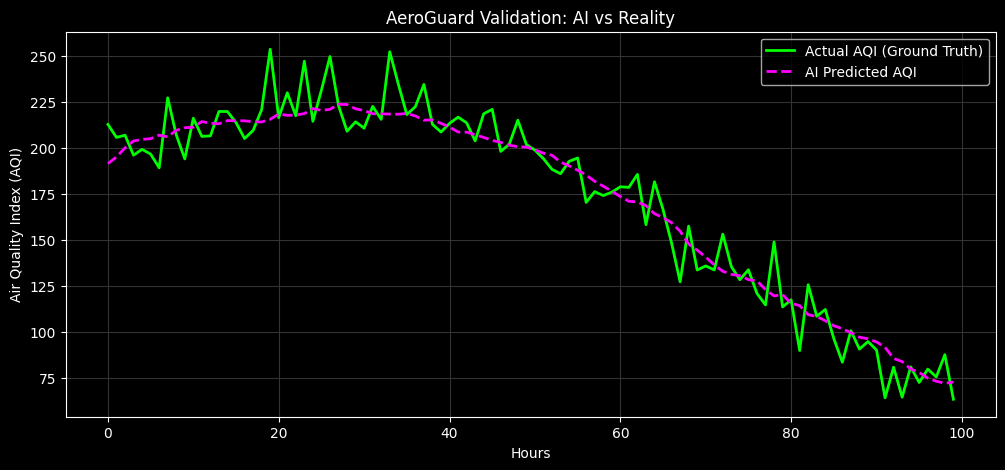

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ==========================================
# 4.5 PREDICTION VERIFICATION & VISUALIZATION
# ==========================================
print("\n🔍 Evaluating Real-World Validation Accuracy...")

# 1. Get predictions from the model
raw_predictions = model.predict(X_val)

# 2. THE FIX: Safely extract the 1D arrays to prevent Broadcasting Errors.
pred_1d = raw_predictions.flatten()

# If Jupyter accidentally handed y_val all 5 columns, extract just the last column (AQI)
if len(y_val.shape) > 1 and y_val.shape[1] > 1:
    actual_1d = y_val[:, -1]
else:
    actual_1d = y_val.flatten()

# 3. Create dummy arrays to reverse the MinMaxScaler safely
dummy_pred = np.zeros((len(pred_1d), 5))
dummy_pred[:, 4] = pred_1d
unscaled_predictions = scaler.inverse_transform(dummy_pred)[:, 4]

dummy_actual = np.zeros((len(actual_1d), 5))
dummy_actual[:, 4] = actual_1d
unscaled_actual = scaler.inverse_transform(dummy_actual)[:, 4]

# 4. Calculate Error Metrics
mae = mean_absolute_error(unscaled_actual, unscaled_predictions)
r2 = r2_score(unscaled_actual, unscaled_predictions)

print(f"✅ Validation R² Score: {r2 * 100:.2f}%")
print(f"⚠️ Mean Absolute Error (MAE): The model is off by an average of {mae:.2f} AQI points.")

# 5. Plot the Graph
plt.style.use('dark_background')
plt.figure(figsize=(12, 5))
plt.plot(unscaled_actual[:100], label="Actual AQI (Ground Truth)", color="#00FF00", linewidth=2)
plt.plot(unscaled_predictions[:100], label="AI Predicted AQI", color="#FF00FF", linestyle="dashed", linewidth=2)
plt.title("AeroGuard Validation: AI vs Reality")
plt.xlabel("Hours")
plt.ylabel("Air Quality Index (AQI)")
plt.legend()
plt.grid(color='#333333')
plt.show()